In [1]:
# os 환경 변수 GEMINI API KEY 입력
import os
from dotenv import load_dotenv

load_dotenv()

True

In [9]:
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from typing import TypedDict, Literal

[Workflow 공식문서](https://docs.langchain.com/oss/python/langgraph/workflows-agents#orchestrator-worker)

# Evaluator-Optimizer

## Model 정의

In [15]:
model = init_chat_model("gpt-5-nano", temperature=0.7)

## State 정의

In [16]:
class AdState(TypedDict):
    product_name: str       # 상품명
    ad_copy: str            # 생성된 광고 문구
    feedback: str           # 피드백
    status: str             # 상태
    iteration_count: int         # 반복 횟수


In [17]:
from pydantic import BaseModel, Field

class EvaluationResult(BaseModel):   
    status: Literal["pass", "fail"] = Field(description="기준 충족 여부")
    feedback: str = Field(description="탈락 시 구체적인 수정사항")


In [18]:
evaluator_llm = model.with_structured_output(EvaluationResult)

## Node 정의

In [19]:
# [Generator] 신입 카피라이터
def copywriter_node(state: AdState):
    product = state["product_name"]
    count = state.get("iteration_count", 0)
    feedback = state.get("feedback")

    print(f"\n--- [Copywriter] 광고 문구 작성 중 (시도: {count + 1}) ---")

    if not feedback:
        # 첫 시도는 좀 건조하게 작성하도록 유도 (Fail을 유발하기 위해)
        prompt = f"'{product}'의 기능 위주로 인스타그램 홍보 문구를 건조하게 작성해줘. 홍보 문구만 답변하고 반드시 20자 이하로 작성하시오."
    else:
        # 피드백 반영
        prompt = f"""
        '{product}' 인스타그램 홍보 문구를 다시 작성해.

        <반드시 지켜야 할 수정 사항>
        {feedback}
        </반드시 지켜야 할 수정 사항>

        <작성 시 반드시 지켜야할 사항>
        홍보 문구만 답변하고 절대 50자 이하로 작성하시오.
        </작성 시 반드시 지켜야할 사항>
        """

    message = model.invoke(prompt)
    ad_copy = message.content

    return {"ad_copy": ad_copy, "iteration_count": count + 1}


In [20]:
# [Evaluator] 감성적인 마케팅 팀장
def manager_node(state: AdState):
    ad_copy = state["ad_copy"]
    print(f"\n--- [Manager] 문구 검수 중 ---")

    print(f"   ㄴ 신입이 쓴 글: {ad_copy}")

    prompt = f"""
    당신은 깐깐한 마케팅 팀장입니다. 신입 사원이 쓴 다음 광고 문구를 평가하세요:

    "{ad_copy}"

    <평가 기준>
    1. (정량) 해시태그(#)가 3개 이상 있어야 합니다.
    2. (정량) '할인' 또는 '특가'라는 단어가 포함되어야 합니다.
    3. (정성 - 중요!) **문구가 너무 설명문 같거나 딱딱하면 안 됩니다. 소비자의 감성을 자극하는 '활기차고 매력적인 톤'이어야 합니다.**
    </평가 기준>

    위 3가지 기준 중 하나라도 부족하면 fail을 주세요.
    특히 3번(톤앤매너)이 부족하다면 "좀 더 감성적으로 쓰세요" 같이 100자 이내로 조언하세요.
    """

    result = evaluator_llm.invoke(prompt)

    print(f"   ㄴ 판정: {result.status.upper()}")
    if result.status == "fail":
        print(f"   ㄴ 지적: {result.feedback}")

    return {"status": result.status, 'feedback': result.feedback}


## 그래프 생성

In [21]:
# 4. 루프 로직
def route_submission(state: AdState):
    status = state["status"]
    count = state["iteration_count"]

    if status == 'pass':
        return END

    if count > 3:
        return END


    else:
        return "copywriter_node"



In [23]:
# 5. 그래프 생성
workflow = StateGraph(AdState)


workflow.add_node("copywriter_node", copywriter_node)
workflow.add_node("manager_node", manager_node)



workflow.add_edge(START, 'copywriter_node')
workflow.add_edge('copywriter_node', 'manager_node')


workflow.add_conditional_edges('manager_node', route_submission, ['copywriter_node', END])


In [24]:
app = workflow.compile()

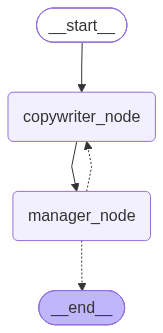

In [25]:
app

## 실행

In [26]:
inputs = {"product_name": "자율주행 자동차"}
result = app.invoke(inputs)


--- [Copywriter] 광고 문구 작성 중 (시도: 1) ---

--- [Manager] 문구 검수 중 ---
   ㄴ 신입이 쓴 글: 자율주행차:안전·경로최적
   ㄴ 판정: FAIL
   ㄴ 지적: 정량 1 미달: 해시태그가 3개 이상 필요합니다. 정량 2 미달: '할인' 또는 '특가' 단어를 포함해야 합니다. 정성 3 미달: 문구가 너무 설명문 같고 딱딱합니다. 조언: 좀 더 감성적으로 쓰세요. 소비자의 감성을 자극하는 활기찬 톤으로 바꿔보세요.

--- [Copywriter] 광고 문구 작성 중 (시도: 2) ---

--- [Manager] 문구 검수 중 ---
   ㄴ 신입이 쓴 글: 자율주행으로 더 자유롭게! 할인 중 #자율주행 #미래모빌리티 #특가
   ㄴ 판정: FAIL
   ㄴ 지적: 1) 해시태그 3개 이상 충족. 2) 할인/특가 포함 충족. 3) 톤앤매너가 다소 딱딱합니다. 좀 더 감성적으로 쓰세요. 예: 자율주행의 자유로움을 활기차게 표현하고 할인을 강조.

--- [Copywriter] 광고 문구 작성 중 (시도: 3) ---

--- [Manager] 문구 검수 중 ---
   ㄴ 신입이 쓴 글: 자율주행의 자유를 느껴봐요, 지금 한정할인! #자율주행 #스마트카 #특가
   ㄴ 판정: PASS
